In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from copy import deepcopy
from tqdm import tqdm
import warnings
from os import listdir
warnings.filterwarnings('ignore')

In [2]:
jobs_raw_df = pd.read_csv("../processed_data/data_isolated_agg.csv", index_col=0)
jobs_raw_df = jobs_raw_df[jobs_raw_df["Num Nodes"] == 8]
inhibitors_raw_df = pd.read_csv("../processed_data/data_inhib_isolated_agg.csv", index_col=0)
inhibitors_raw_df = inhibitors_raw_df[inhibitors_raw_df["Num Nodes"] == 8]
job_inh_raw_df = pd.read_csv("../processed_data/data_inhib_coscheduled_agg.csv", index_col=0)
job_inh_raw_df = job_inh_raw_df[job_inh_raw_df["Num Nodes"] == 8]
pair_raw_df = pd.read_csv("../processed_data/data_coscheduled_agg.csv", index_col=0)
pair_raw_df = pair_raw_df[pair_raw_df["Num Nodes"] == 8]

In [2]:
# Preprocess data #1

# Isolated jobs
jobs_df = pd.DataFrame()
jobs_df["job_id"] = jobs_raw_df["App"]
jobs_df["mpi_time"] = jobs_raw_df["MPI Time Average Mean"]
jobs_df["comm_frac"] = jobs_raw_df["MPI Time Average Mean"] / jobs_raw_df["App Time Average Mean"]
jobs_df["total_msgs"] = jobs_raw_df["Total Messages Sent Mean"]
jobs_df["total_bytes"] = jobs_raw_df["Total Bytes Sent Mean"]

# Isolated inhibitors
inhibitors_df = pd.DataFrame()
columns_to_use = ["Num Nodes", "Inhib Message Size", "Inhib Wait Time (us)", "Inhib Comm Sparsity"]
selected_data = inhibitors_raw_df[columns_to_use]
inhibitors_df["inhib_id"] = (selected_data
                             .astype(str)
                             .agg('_'.join, axis=1))
inhibitors_df["msg_size"] = inhibitors_raw_df["Inhib Message Size"]
inhibitors_df["wait_time"] = inhibitors_raw_df["Inhib Wait Time (us)"]
inhibitors_df["comm_sparsity"] = inhibitors_raw_df["Inhib Comm Sparsity"]
inhibitors_df["mpi_time"] = inhibitors_raw_df["Inhib MPI Time Average Mean"]
inhibitors_df["comm_frac"] = inhibitors_raw_df["Inhib MPI Time Average Mean"] / inhibitors_raw_df["Inhib App Time Average Mean"]
inhibitors_df["total_msgs"] = inhibitors_raw_df["Inhib Total Messages Sent Mean"]
inhibitors_df["total_bytes"] = inhibitors_raw_df["Inhib Total Bytes Sent Mean"]

# Co-scheduled job and inhibitors
job_inh_df = pd.DataFrame()
job_inh_df["job_id"] = job_inh_raw_df["App"]
columns_to_use = ["Num Nodes", "Inhib Message Size", "Inhib Wait Time (us)", "Inhib Comm Sparsity"]
selected_data = job_inh_raw_df[columns_to_use]
job_inh_df["inhib_id"] = (selected_data
                             .astype(str)
                             .agg('_'.join, axis=1))
job_inh_slowdowns = []
for i in job_inh_raw_df.iloc:
    iso_time = (jobs_df[jobs_df["job_id"] == i["App"]])["mpi_time"].max()
    coscheduled_time = i["MPI Time Average Mean"]
    if (coscheduled_time < iso_time):
        slowdown = 1
    else:
        slowdown = coscheduled_time/iso_time
    job_inh_slowdowns.append(slowdown)
job_inh_df["slowdown"] = job_inh_slowdowns

# Co-scheduled jobs
pair_df = pd.DataFrame()
pair_df["jobA_id"] = pair_raw_df["App A"]
pair_df["jobB_id"] = pair_raw_df["App B"]
pair_slowdowns_a = []
pair_slowdowns_b = []
for i in pair_raw_df.iloc:
    iso_time_a = (jobs_df[jobs_df["job_id"] == i["App A"]])["mpi_time"].max()
    iso_time_b = (jobs_df[jobs_df["job_id"] == i["App B"]])["mpi_time"].max()
    coscheduled_time_a = i["App A MPI Time Average Mean"]
    coscheduled_time_b = i["App B MPI Time Average Mean"]
    if (coscheduled_time_a < iso_time_a):
        slowdown_a = 1
    else:
        slowdown_a = coscheduled_time_a/iso_time_a
    pair_slowdowns_a.append(slowdown_a)
    if (coscheduled_time_b < iso_time_b):
        slowdown_b = 1
    else:
        slowdown_b = coscheduled_time_b/iso_time_b
    pair_slowdowns_b.append(slowdown_b)
pair_df["slowdown_A"] = pair_slowdowns_a
pair_df["slowdown_B"] = pair_slowdowns_b

NameError: name 'jobs_raw_df' is not defined

In [6]:
jobs_df.to_csv("utils/few_shot/data/jobs.csv")
inhibitors_df.to_csv("utils/few_shot/data/inhibitors.csv")
job_inh_df.to_csv("utils/few_shot/data/job_inh.csv")
pair_df.to_csv("utils/few_shot/data/pair.csv")

In [3]:
# Few shot utils have the experimentation pipeline. Rest of this notebook analyzes the results from the pipeline

In [5]:
# Add times to prediction datasets

jobs_df = pd.read_csv("utils/few_shot/data/jobs.csv", index_col=0)
inhibitors_df = pd.read_csv("utils/few_shot/data/inhibitors.csv", index_col=0)
job_inh_df = pd.read_csv("utils/few_shot/data/job_inh.csv", index_col=0)
pair_df = pd.read_csv("utils/few_shot/data/pair.csv", index_col=0)

def append_times_to_preds(preds: pd.DataFrame):
    app_A_iso_times = []
    for i in preds.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]
        app_A_iso_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_A_iso_times.append(app_A_iso_time)
    preds["app_A_iso_time"] = app_A_iso_times
    preds["app_A_y_true_time"] = preds["app_A_iso_time"] * preds["y_true"]
    preds["app_A_y_pred_time"] = preds["app_A_iso_time"] * preds["y_pred"]

train_df = pd.read_csv("utils/few_shot/output/train.csv")
test_df= pd.read_csv("utils/few_shot/output/test.csv")

append_times_to_preds(train_df)
append_times_to_preds(test_df)
# train_df

In [11]:
import matplotlib.pyplot as plt

def plot_times(df):
    for row in df.iloc:
        """Create a bar plot for a single row showing app_A_iso_time, app_A_y_true_time, app_A_y_pred_time"""
        times = [
            row['app_A_iso_time'],
            row['app_A_y_true_time'],
            row['app_A_y_pred_time']
        ]
        
        labels = ['Iso Time', 'Y True Time', 'Y Pred Time']
        apps = f"{row['app_A']} vs {row['app_B']}"
        
        fig, ax = plt.subplots(figsize=(8, 6))
        x = range(len(labels))
        bars = ax.bar(x, times, color=['#1f77b4', '#2ca02c', '#ff7f0e'])
        
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Time Comparison: {apps}')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.grid(axis='y', alpha=0.3)
        
        ax.bar_label(bars, padding=3)
        
        plt.tight_layout()
        plt.show()

# plot_times(test_df)
train_mse = mean_squared_error(train_df["app_A_y_true_time"], train_df["app_A_y_pred_time"])
test_mse = mean_squared_error(test_df["app_A_y_true_time"], test_df["app_A_y_pred_time"])
iso_mse = mean_squared_error(test_df["app_A_y_true_time"], test_df["app_A_iso_time"])

train_mae = mean_absolute_error(train_df["app_A_y_true_time"], train_df["app_A_y_pred_time"])
test_mae = mean_absolute_error(test_df["app_A_y_true_time"], test_df["app_A_y_pred_time"])
iso_mae = mean_absolute_error(test_df["app_A_y_true_time"], test_df["app_A_iso_time"])

train_mape = mean_absolute_percentage_error(train_df["app_A_y_true_time"], train_df["app_A_y_pred_time"]) * 100
test_mape = mean_absolute_percentage_error(test_df["app_A_y_true_time"], test_df["app_A_y_pred_time"]) * 100
iso_mape = mean_absolute_percentage_error(test_df["app_A_y_true_time"], test_df["app_A_iso_time"]) * 100

train_rmse = np.sqrt(train_mse) 
test_rmse = np.sqrt(test_mse) 
iso_rmse = np.sqrt(iso_mse) 

print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Train MAE:", train_mae)
print("Train MAPE:", train_mape, "%")
print(50*"-")
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test MAE:", test_mae)
print("Test MAPE:", test_mape, "%")
# print(50*"-")
# print("Iso MSE:", iso_mse)
# print("Iso RMSE:", iso_rmse)
# print("Iso MAE:", iso_mae)
# print("Iso MAPE:", iso_mape, "%")

Train MSE: 49.93494405032792
Train RMSE: 7.066466164238524
Train MAE: 3.0414117627696813
Train MAPE: 8.461858552701557 %
--------------------------------------------------
Test MSE: 387.6743435030516
Test RMSE: 19.68944751645032
Test MAE: 13.6512342144195
Test MAPE: 12.464880105694983 %


## Few Shot Learning Experiment Plan

## Modes
1) random_split: Random split between training and testing pairs.
2) one_known: Exactly one of the 2 apps in a testing pair are from training.
3) zero_shot: Both apps in testing pairs are unknown.

### Random Split 
1) Train-test ratio (0.5 - 0.9)
2) Number of random iterations

### One Known
1) Number of apps in training
2) Specific apps in training

### Zero Shot
1) Number of apps in training
2) Specific apps in training

In [40]:
# Preprocess experiment data

header = ["type", "eval_type", "train_frac", "random_iter",
          "train_apps", "num_train_apps", "app_A", "app_B", "y_true", "y_pred", 
          "app_A_iso_mpi_time", "app_B_iso_mpi_time"]

experiment_data = []
# Random split
files = listdir("utils/few_shot/experiment_data/random_split")
for f in files:
    _, _, train_frac, random_iter = f.split("_")
    train_df = pd.read_csv(f"utils/few_shot/experiment_data/random_split/{f}/train.csv")
    test_df = pd.read_csv(f"utils/few_shot/experiment_data/random_split/{f}/test.csv")

    for i in train_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()
        
        experiment_data.append(["train", "random_split", float(train_frac), int(random_iter),
                                  "", i["app_A"], i["app_B"], i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])
    for i in test_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()
        
        experiment_data.append(["test", "random_split", float(train_frac), int(random_iter),
                                  "", "", i["app_A"], i["app_B"], i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])


# One known
files = listdir("utils/few_shot/experiment_data/one_known")
for f in files:
    elems = f.split("_")
    train_apps = elems[2:]
    train_apps_str = ""
    for idx, i in enumerate(train_apps):
        train_apps_str += i
        if (idx+1 == len(train_apps)):
            continue
        else:
            train_apps_str += ","
    train_df = pd.read_csv(f"utils/few_shot/experiment_data/one_known/{f}/train.csv")
    test_df = pd.read_csv(f"utils/few_shot/experiment_data/one_known/{f}/test.csv")

    for i in train_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()

        experiment_data.append(["train", "one_known", "", "",
                                  train_apps_str, len(elems[2:]), i["app_A"], i["app_B"],
                                  i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])

    for i in test_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()

        experiment_data.append(["test", "one_known", "", "",
                                  train_apps_str, len(elems[2:]), i["app_A"], i["app_B"],
                                  i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])


# Zero shot
files = listdir("utils/few_shot/experiment_data/zero_shot")
for f in files:
    elems = f.split("_")
    train_apps = elems[2:]
    train_apps_str = ""
    for idx, i in enumerate(train_apps):
        train_apps_str += i
        if (idx+1 == len(train_apps)):
            continue
        else:
            train_apps_str += ","
    train_df = pd.read_csv(f"utils/few_shot/experiment_data/zero_shot/{f}/train.csv")
    test_df = pd.read_csv(f"utils/few_shot/experiment_data/zero_shot/{f}/test.csv")

    for i in train_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()

        experiment_data.append(["train", "zero_shot", "", "",
                                  train_apps_str, len(elems[2:]), i["app_A"], i["app_B"],
                                  i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])

    for i in test_df.iloc:
        app_A = i["app_A"]
        app_B = i["app_B"]

        app_A_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_A]["mpi_time"].max()
        app_B_iso_mpi_time = jobs_df[jobs_df["job_id"] == app_B]["mpi_time"].max()

        experiment_data.append(["test", "zero_shot", "", "",
                                  train_apps_str, len(elems[2:]), i["app_A"], i["app_B"],
                                  i["y_true"], i["y_pred"],
                                  app_A_iso_mpi_time, app_B_iso_mpi_time])


experiment_data_df = pd.DataFrame(experiment_data)
experiment_data_df.columns = header
experiment_data_df["app_A_cosched_true"] = experiment_data_df["app_A_iso_mpi_time"] * experiment_data_df["y_true"]
experiment_data_df["app_A_cosched_pred"] = experiment_data_df["app_A_iso_mpi_time"] * experiment_data_df["y_pred"]
experiment_data_df.to_csv("utils/few_shot/data/experiment_data.csv")

In [26]:
experiment_data_df[experiment_data_df["eval_type"] == "zero_shot"]

,type,eval_type,train_frac,random_iter,train_apps,app_A,app_B,y_true,y_pred,app_A_iso_mpi_time,app_B_iso_mpi_time,app_A_cosched_true,app_A_cosched_pred
136142,train,zero_shot,,,"beatnik,fiesta,laghos,lammps,quicksilver",quicksilver,laghos,1.011539,1.073618,133.995497,54.944978,135.541620,143.859968
136143,train,zero_shot,,,"beatnik,fiesta,laghos,lammps,quicksilver",fiesta,fiesta,1.000000,1.077858,65.675446,65.675446,65.675446,70.788780
136144,train,zero_shot,,,"beatnik,fiesta,laghos,lammps,quicksilver",quicksilver,lammps,1.023853,1.078896,133.995497,17.381222,137.191748,144.567211
136145,train,zero_shot,,,"beatnik,fiesta,laghos,lammps,quicksilver",beatnik,laghos,1.159186,1.111700,99.906362,54.944978,115.810044,111.065860
136146,train,zero_shot,,,"beatnik,fiesta,laghos,lammps,quicksilver",beatnik,quicksilver,1.165774,1.178119,99.906362,133.995497,116.468249,117.701625
...,...,...,...,...,...,...,...,...,...,...,...,...,...
238179,test,zero_shot,,,"amg,kripke,laghos,minife,minivite,quicksilver",minivite,amg,1.041788,1.054104,51.597266,12.778086,53.753405,54.388907
238180,test,zero_shot,,,"amg,kripke,laghos,minife,minivite,quicksilver",quicksilver,minivite,1.020649,1.044908,133.995497,51.597266,136.762428,140.012989
238181,test,zero_shot,,,"amg,kripke,laghos,minife,minivite,quicksilver",minivite,minife,1.064552,1.052634,51.597266,13.601356,54.927957,54.313030
238182,test,zero_shot,,,"amg,kripke,laghos,minife,minivite,quicksilver",kripke,laghos,1.036983,1.063759,17.006585,54.944978,17.635548,18.090903


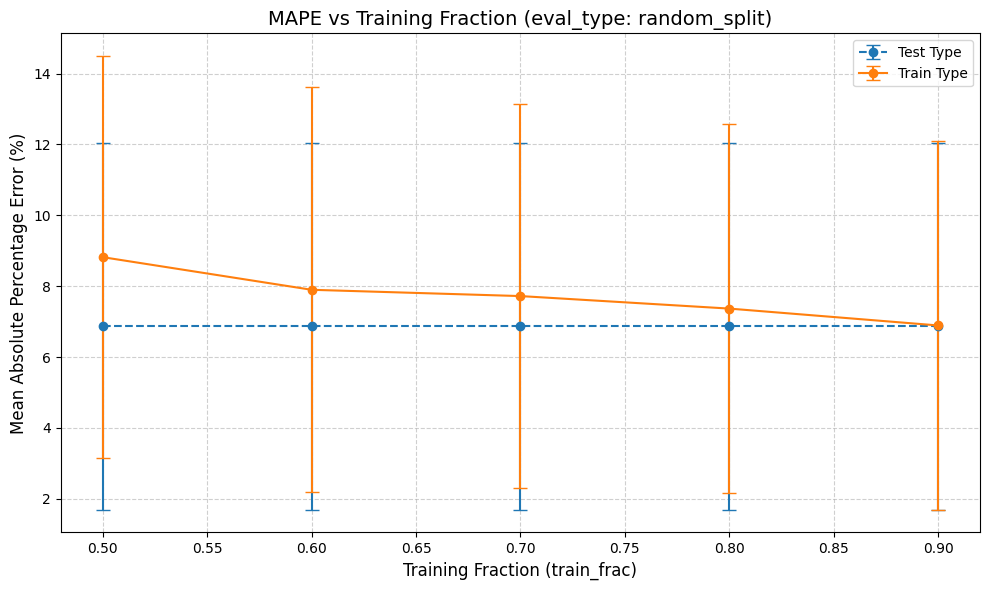

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Filter the dataset for 'random_split' eval_type
# We drop rows where train_frac is NaN just to be safe, though eval_type filter handles most of it
df_filtered = experiment_data_df[experiment_data_df['eval_type'] == 'random_split'].copy()

# 2. Calculate Mean Absolute Percentage Error (MAPE) per row
# Formula: abs(true - pred) / true * 100
# We add a small epsilon to avoid division by zero if 'true' value is 0
epsilon = 1e-10

df_filtered['mape'] = abs(df_filtered['app_A_cosched_true'] - df_filtered['app_A_cosched_pred']) / \
                      (df_filtered['app_A_cosched_true'] + epsilon) * 100

# 3. Aggregate the data
# Group by 'train_frac' and 'type' to get the mean MAPE and standard deviation
# This effectively averages across different 'random_iter' instances for each training fraction
grouped_data = df_filtered.groupby(['train_frac', 'type'])['mape'].agg(['mean', 'std']).reset_index()

# Sort by train_frac to ensure lines connect correctly on the plot
grouped_data = grouped_data.sort_values(['type', 'train_frac'])

# 4. Create the Plot
plt.figure(figsize=(10, 6))

# Loop through unique 'type' values (train and test) to plot separate lines
for t in grouped_data['type'].unique():
    subset = grouped_data[grouped_data['type'] == t]
    
    # Plotting with error bars representing 1 standard deviation
    plt.errorbar(
        x=subset['train_frac'], 
        y=subset['mean'], 
        yerr=subset['std'],  # This creates the 1 std dev error bars
        fmt='o-',            # 'o' for marker, '-' for line
        label=f"{t.capitalize()} Type",
        capsize=5,           # Adds caps to the error bars for better visibility
        linestyle='--' if t == 'test' else 'solid' # Differentiate lines slightly if desired
    )

# 5. Formatting and Labels
plt.xlabel('Training Fraction (train_frac)', fontsize=12)
plt.ylabel('Mean Absolute Percentage Error (%)', fontsize=12)
plt.title('MAPE vs Training Fraction (eval_type: random_split)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()


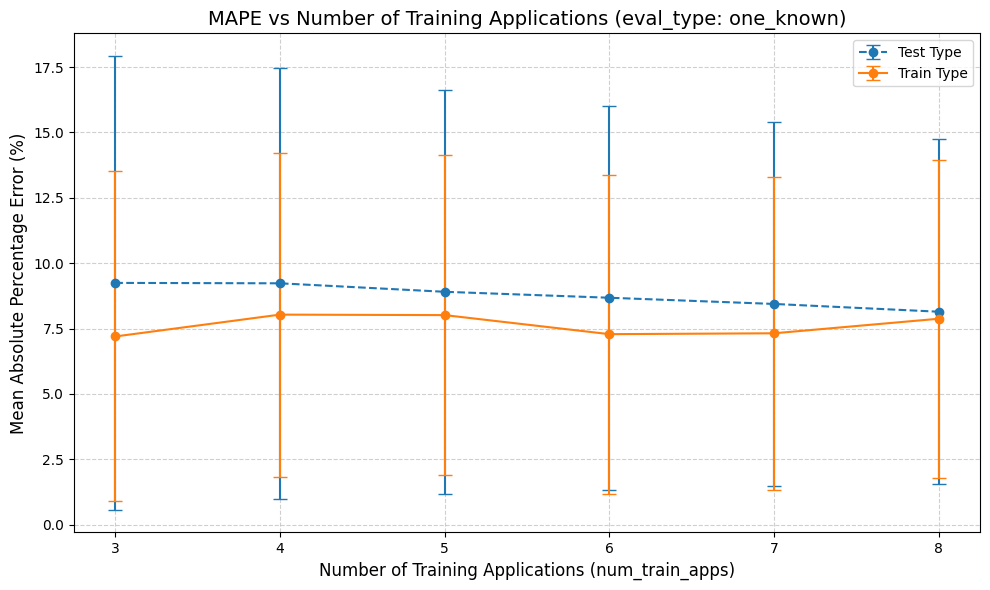

In [41]:
# 1. Filter the dataset for 'one_known' eval_type
df_filtered = experiment_data_df[experiment_data_df['eval_type'] == 'one_known'].copy()

# 2. Calculate Mean Absolute Percentage Error (MAPE) per row
# Formula: abs(true - pred) / true * 100
# We add a small epsilon to avoid division by zero if 'true' value is 0
epsilon = 1e-10

df_filtered['mape'] = abs(df_filtered['app_A_cosched_true'] - df_filtered['app_A_cosched_pred']) / \
                      (df_filtered['app_A_cosched_true'] + epsilon) * 100

# 3. Aggregate the data
# Group by 'num_train_apps' and 'type' to get the mean MAPE and standard deviation
grouped_data = df_filtered.groupby(['num_train_apps', 'type'])['mape'].agg(['mean', 'std']).reset_index()

# Sort by 'num_train_apps' to ensure lines connect correctly on the plot
grouped_data = grouped_data.sort_values(['type', 'num_train_apps'])

# 4. Create the Plot
plt.figure(figsize=(10, 6))

# Loop through unique 'type' values (train and test) to plot separate lines
for t in grouped_data['type'].unique():
    subset = grouped_data[grouped_data['type'] == t]
    
    # Plotting with error bars representing 1 standard deviation
    plt.errorbar(
        x=subset['num_train_apps'], 
        y=subset['mean'], 
        yerr=subset['std'],  # This creates the 1 std dev error bars
        fmt='o-',            # 'o' for marker, '-' for line
        label=f"{t.capitalize()} Type",
        capsize=5,           # Adds caps to the error bars for better visibility
        linestyle='--' if t == 'test' else 'solid'  # Differentiate train and test lines
    )

# 5. Formatting and Labels
plt.xlabel('Number of Training Applications (num_train_apps)', fontsize=12)
plt.ylabel('Mean Absolute Percentage Error (%)', fontsize=12)
plt.title('MAPE vs Number of Training Applications (eval_type: one_known)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()


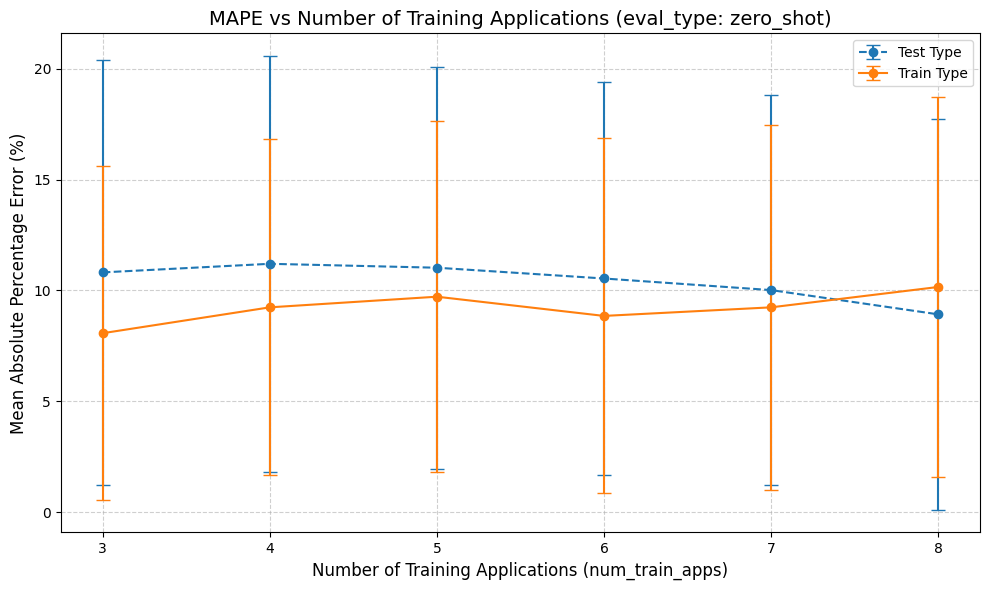

In [42]:
# 1. Filter the dataset for 'one_known' eval_type
df_filtered = experiment_data_df[experiment_data_df['eval_type'] == 'zero_shot'].copy()

# 2. Calculate Mean Absolute Percentage Error (MAPE) per row
# Formula: abs(true - pred) / true * 100
# We add a small epsilon to avoid division by zero if 'true' value is 0
epsilon = 1e-10

df_filtered['mape'] = abs(df_filtered['app_A_cosched_true'] - df_filtered['app_A_cosched_pred']) / \
                      (df_filtered['app_A_cosched_true'] + epsilon) * 100

# 3. Aggregate the data
# Group by 'num_train_apps' and 'type' to get the mean MAPE and standard deviation
grouped_data = df_filtered.groupby(['num_train_apps', 'type'])['mape'].agg(['mean', 'std']).reset_index()

# Sort by 'num_train_apps' to ensure lines connect correctly on the plot
grouped_data = grouped_data.sort_values(['type', 'num_train_apps'])

# 4. Create the Plot
plt.figure(figsize=(10, 6))

# Loop through unique 'type' values (train and test) to plot separate lines
for t in grouped_data['type'].unique():
    subset = grouped_data[grouped_data['type'] == t]
    
    # Plotting with error bars representing 1 standard deviation
    plt.errorbar(
        x=subset['num_train_apps'], 
        y=subset['mean'], 
        yerr=subset['std'],  # This creates the 1 std dev error bars
        fmt='o-',            # 'o' for marker, '-' for line
        label=f"{t.capitalize()} Type",
        capsize=5,           # Adds caps to the error bars for better visibility
        linestyle='--' if t == 'test' else 'solid'  # Differentiate train and test lines
    )

# 5. Formatting and Labels
plt.xlabel('Number of Training Applications (num_train_apps)', fontsize=12)
plt.ylabel('Mean Absolute Percentage Error (%)', fontsize=12)
plt.title('MAPE vs Number of Training Applications (eval_type: zero_shot)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()
